# Plotting with Python

This script will plot the results of your manual analysis of the time fish spent in each section of the tank

Your tasks will be as follows.  See the sample plot and description of the anlaysis below:
1. Upload the CSV file
2. Update the *path* to the CSV file (where should the computer look for this file?)
3. Update which columns you want to read in (?)
4. Update the line colors/styles
5. Put labels on the graph
6. Answer the questions about your graph/analysis

## A description and sample plot



### The first thing we always need to do is import *packages* that we will use.  

Run the below block of code by selecting the code block and hitting "shift + enter."  This will read in the packages.  

In [17]:
import pandas as pd #pandas gives an helpful way to deal with two-dimensional data (columns and rows)
import numpy as np #this has more math options
import matplotlib.pyplot as plt #plotting.  Based on MATLAB

### Now we need to read in the data file.

In the below cell, replace the words `'your file'` with the *path* and *name* of your file.  

To get the file with a path select the three dots next to the file name in the file tree on the left and select **Copy path**

You can then paste this path where it says `'your file'`.  Keep the apostrophere's on either side of the filename! This tells the computer to read it direclty as it's shown.

The `/` tell the computer what *directory* (or folder) to look in.

Run the cell below and look at the ouptut.  That's your data that is now all held in the variable `df`

`df` stands for **dataframe** which is what pandas calls a table of data

In [9]:
df = pd.read_csv('/content/KK__LDT__sample-data.csv') # read in the data
df #print the data

#df['Region']

### Find the total amount of time in each line

In [ ]:
df['time_delta'] = df['End']-df['Start ']

### Group the data

The `groupby` function is specific to pandas and takes all of the data and "groups" it based on the columns we input.  The lines below groups the data by each fish identfier *and* region (i.e., light or dark).

We will then be able to *access* these groups later

In [11]:
df_fish = df.groupby(['Fish','Region'])

In [25]:
df_fish.head()

,Fish,Region,Start,End,time_delta
0,5597,LightSide,0.00,58.76,58.76
1,5597,LightSide,62.01,70.00,7.99
2,5597,LightSide,75.03,77.19,2.16
3,5597,LightSide,78.10,84.21,6.11
4,5597,LightSide,87.38,93.42,6.04
56,5597,DarkSide,58.76,62.01,3.25
57,5597,DarkSide,70.00,75.03,5.03
58,5597,DarkSide,77.19,78.10,0.91
59,5597,DarkSide,84.21,87.38,3.17
60,5597,DarkSide,93.42,99.71,6.29


### Sum up the data in one-minute increments.  

[5597 9797 3002]
5597
9797
3002
[  0  60 120 180 240 300 360 420 480 540]
[58.76  0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
[58.76 34.87  0.    0.    0.    0.    0.    0.    0.    0.  ]
[58.76 34.87 39.41  0.    0.    0.    0.    0.    0.    0.  ]
[58.76 34.87 39.41 46.24 16.17  0.    0.    0.    0.    0.  ]
[58.76 34.87 39.41 46.24 31.02 28.23  0.    0.    0.    0.  ]
[58.76 34.87 39.41 46.24 31.02 56.8   0.    0.    0.    0.  ]
[58.76 34.87 39.41 46.24 31.02 56.8  44.93  5.53  0.    0.  ]
[58.76 34.87 39.41 46.24 31.02 56.8  44.93 48.44  0.78  0.  ]
[58.76 34.87 39.41 46.24 31.02 56.8  44.93 48.44 45.9  26.84]
[58.76 34.87 39.41 46.24 31.02 56.8  44.93 48.44 45.9  54.07]
[60.   1.9  0.   0.   0.   0.   0.   0.   0.   0. ]
[60.   31.95  1.15  0.    0.    0.    0.    0.    0.    0.  ]
[60.   31.95 19.04  7.82  0.    0.    0.    0.    0.    0.  ]
[60.   31.95 19.04 39.82  2.77  0.    0.    0.    0.    0.  ]
[60.   31.95 19.04 39.82 27.7   0.21  0.    0.    0.    0.  ]
[60.  

/tmp/ipykernel_13164/391276764.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[i].legend()
/tmp/ipykernel_13164/391276764.py:78: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  fig.legend([axs[0]], labels=['Light Side','Dark Side'],loc="upper right")


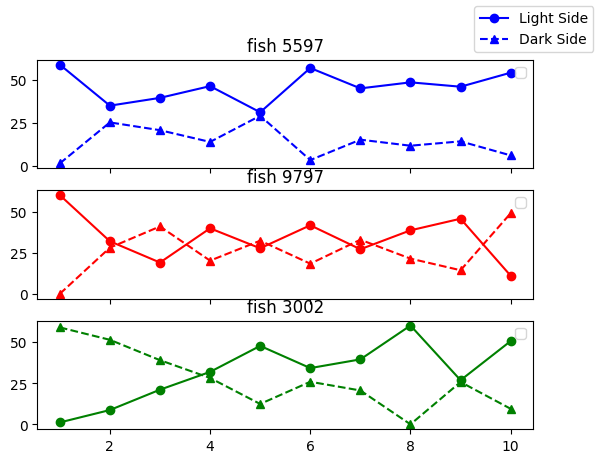

In [16]:
unique_fish = df['Fish'].unique()
print(unique_fish)
for u in unique_fish:
  print(u)

total_mins = 9
minutes = np.arange(0,60*total_mins+60,60) #+1 b/c not inclusive
print(minutes)
minute_binsL = np.zeros(len(minutes))
minute_binsD = np.zeros(len(minutes))
x_axis = np.arange(1,total_mins+2,1)
color_array = ['blue','red','green','magenta','teal','black']
plot_color = color_array[0:len(unique_fish)]

fig, axs = plt.subplots(len(unique_fish)) #the same number of plots as there are fish

for i,u in enumerate(unique_fish):
  dataL = df_fish.get_group((u,'LightSide'))
  dataD = df_fish.get_group((u,'DarkSide'))
  #print(dataD.tail)

  for j,t in enumerate(minutes): #starting at 0 seconds, ending at 600 seconds, every 60 s
    #if u == 3002 and t == 420:
      #print('before')
      #print(minute_binsL[j])
    minute_binsL[j] = minute_binsL[j] + np.round(dataL[(dataL['Start '] >= t) & (dataL['End'] < t+60)]['time_delta'].sum(),2)
    minute_binsD[j] = minute_binsD[j] + np.round(dataD[(dataD['Start '] >= t) & (dataD['End'] < t+60)]['time_delta'].sum(),2)

    #if u == 3002 and t == 420:
      #print(f'the offending sum: {np.round(dataL[(dataL['Start '] >= t) & (dataL['End'] < t+60)]['time_delta'].sum(),2)}')
      #print(minute_binsL[j])


    for l in range(len(dataL)):
      if (dataL['Start '].iloc[l] < t +60 ) and (dataL['End'].iloc[l] > t + 60):
        # if u == 3002:
        #   print(f'at {t} to {t+60}')
        #   print(f'{dataL['Start '].iloc[l]}   end: {dataL['End'].iloc[l]}')
        #   print(f'original: {minute_binsL[j]}')

        if (t > dataL['Start '].iloc[l] ): #check if the starting time is ALSO between these times:
          minute_binsL[j] = np.round(minute_binsL[j] + ( (t+60) - t),2)
          print(f'new total: {minute_binsL[j]}')
        else:
          #print(f' difference: {(t+60) - dataL['Start '].iloc[l]}')
          #print(f'new total: {minute_binsL[j]}')
          minute_binsL[j] = np.round(minute_binsL[j] + ( (t+60) - dataL['Start '].iloc[l]),2)
          if dataL['End'].iloc[l] > t+120:
            continue
          else:
            minute_binsL[j+1] = np.round(minute_binsL[j+1] + np.abs((t+60) - dataL['End'].iloc[l]),2)

    for l in range(len(dataD)):
      # if u == 3002:
      #   print(f'at {t} to {t+60}')
      #   print(f'{dataD['Start '].iloc[l]}   end: {dataD['End'].iloc[l]}')
      #   print(f'original: {minute_binsD[j]}')
      #   print(f' difference: {(t+60) - dataD['Start '].iloc[l]}')
      #   print(f' new total: {np.round(minute_binsD[j] + ( (t+60) - dataD['Start '].iloc[l]),2)}' )
      #  print('in if')
      if (dataD['Start '].iloc[l] < t +60 ) and (dataD['End'].iloc[l] > t + 60):
        minute_binsD[j] = np.round(minute_binsD[j] + ( (t+60) - dataD['Start '].iloc[l]),2)
        minute_binsD[j+1] = np.round(minute_binsD[j+1] + np.abs((t+60) - dataD['End'].iloc[l]),2)
    #print(f'{t} to {t+60}:')
    print(minute_binsL)
    #print(minute_binsD)

  axs[i].plot(x_axis,minute_binsL,marker='o',color=plot_color[i])
  axs[i].plot(x_axis,minute_binsD,marker='^',color=plot_color[i],linestyle='dashed')
  axs[i].legend()
  axs[i].set_title(f'fish {u}')
  del(minute_binsD,minute_binsL,dataL,dataD)
  minute_binsL = np.zeros(len(minutes))
  minute_binsD = np.zeros(len(minutes))

for ax in fig.get_axes():
    ax.label_outer()
fig.legend([axs[0]], labels=['Light Side','Dark Side'],loc="upper right")
    #print(minute_bins)
  #break
